Check which redshift drives the delta chi2 between fits

In [30]:
from escripts import eMCMC
from escripts import edata
from escripts import eplots

In [94]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
              '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt',
             '/Users/eb35267/Desktop/code/home/data/Chemerynska+25.txt',
             '/Users/eb35267/Desktop/code/home/data/Donnan24_high_z.txt',
             '/Users/eb35267/Desktop/code/home/data/Kokorev+25.txt',
             '/Users/eb35267/Desktop/code/home/data/Weibel+25_upper_limits.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'Chemerynska+25', r'Donnan+24 ultra high-$z$', 'Kokorev+25', 'Weibel+25']
include = [True, True, False, False, False, False]
sorted_data = edata.get_sorted(file_names, data_labels, include_in_likelihood=include)

In [95]:
params = eMCMC.build_param_data({'beta':{'fit': False, 'value': -1.49}, 'dbetadz':{'fit': False, 'value': 0.22}})
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [ ]:
no_z_ev = [1.02, -0.02, 11.54, -0.01, -1.45, -0.16, 0.58, 0, -1.1, 0.79]
no_m_ev = [0.49, -0.02, 11.76, -0.04, -1.34, -0.12, 0.53, 0.24, 0, 0.67]

In [96]:
chi2_no_z = -2*my_UVLF.log_like(no_z_ev, return_by_z = True)

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


In [97]:
chi2_no_m = -2*my_UVLF.log_like(no_m_ev, return_by_z = True)

Text(0.5, 1.0, 'Comparing $d\\sigma_{\\rm{UV}}/dz = 0$ and $d\\sigma_{\\rm{UV}}/d\\log M_{h} = 0$ fits')

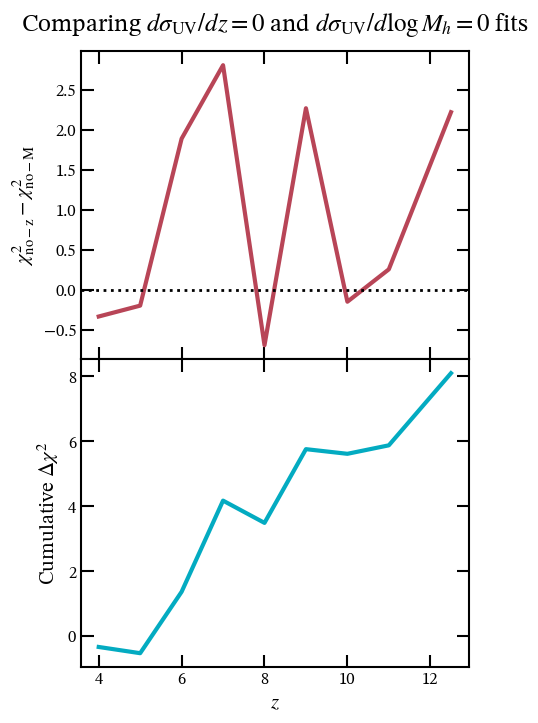

In [98]:
fig, ax = plt.subplots(2, 1, sharex = True)
fig.set_size_inches(5, 8)
plt.subplots_adjust(hspace = 0)
delta_chi2 = chi2_no_z - chi2_no_m
ax[0].plot(my_UVLF.zs, delta_chi2)
ax[0].axhline(0, color = 'black', ls = 'dotted', lw = 2)
ax[0].set_ylabel(r'$\chi^2_{\rm{no-z}} - \chi^2_{\rm{no-M}}$')
ax[1].plot(my_UVLF.zs, np.cumsum(delta_chi2), color = eplots.turquoise)
ax[1].set_ylabel(r'Cumulative $\Delta \chi^2$')
ax[1].set_xlabel(r'$z$')
ax[0].set_title(r'Comparing $d\sigma_{\rm{UV}}/dz = 0$ and $d\sigma_{\rm{UV}}/d\log M_{h} = 0$ fits')

In [99]:
fig.savefig('/Users/eb35267/Desktop/code/figures/deltachi2_over_z.png')